# Emerging Technologies: Quantum Algorithms

A comparative study of classical and quantum approaches to the Deutsch-Jozsa problem.

**Module:** Emerging Technologies  
**Academic Year:** 2025/2026  
**Author:** Eric Murray

### Imports & Housekeeping

In [48]:
# Standard library imports
import random
from itertools import product

# For later visualization and analysis
import matplotlib.pyplot as plt
import numpy as np

## Problem 1: Generating Random Boolean Functions

### Quantum vs Classical Computing

Imagine someone gives you a black box - a function you can't see inside. You can only interact with it by giving it 4 True/False values and seeing what it returns (True or False).

Your task: figure out if this mystery function is **constant** (always returns the same answer) or **balanced** (returns True for exactly half the inputs, False for the other half).

**The Classical Approach:**

You start testing:
- Input: (False, False, False, False) → True
- Input: (True, False, False, False) → True  
- Input: (False, True, False, False) → True

So far all True... but you still don't know! It could be:
- **Constant:** Always returns True (for all 16 possible inputs)
- **Balanced:** Returns True for 8 inputs, you just haven't hit a False one yet

You keep testing... after 8 tests that all return True, you STILL can't be certain. Only on the 9th test:
- If it returns True → Must be constant (more than 8 True values)
- If it returns False → Must be balanced (exactly 8 True, rest False)

For 4-bit functions: worst case needs 9 queries. For 10-bit functions: 513 queries. This grows exponentially.

**The Quantum Solution:**

The [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) is a quantum algorithm that solves this same problem with just **one** query, regardless of how many input bits there are. It achieves this using quantum superposition, where qubits can represent all possible input combinations simultaneously.

To test this quantum algorithm in later problems, we need a way to generate random test functions.

### Function Types

A [Boolean function](https://en.wikipedia.org/wiki/Boolean_function) takes Boolean inputs (True/False) and returns a Boolean output. For functions with 4 inputs, there are 2⁴ = 16 possible input combinations.

**Constant Function:**  
Returns the same value for all inputs. Only two possibilities:
- Always returns `False` 
- Always returns `True`

**Balanced Function:**  
Returns `True` for exactly half the inputs (8 out of 16) and `False` for the other half (8 out of 16).

### Implementation Goal

Our `random_constant_balanced()` function randomly generates one of these special functions. Each time we call it, we get a new random function that is guaranteed to be either constant or balanced.

In [49]:
def random_constant_balanced():
    """
    Generate a random boolean function that is either constant or balanced.

    Returns a function that takes 4 boolean inputs and returns a boolean.
    """

    # Generate all 16 possible input combinations.
    all_inputs = list(product([False, True], repeat=4))

    # Create a lookup dictionary for the function.
    lookup = {}

    # Randomly decide if the function is constant or balanced.
    is_constant = random.choice([True, False])

    if is_constant:
        # Constant - all inputs map to the same output.
        constant_value = random.choice([False, True])
        for input_combo in all_inputs:
            lookup[input_combo] = constant_value
    else:
        # Balanced - half inputs map to False, half to True.
        shuffled_inputs = all_inputs.copy()
        random.shuffle(shuffled_inputs)

        # First 8 inputs return True
        for i in range(8):
            lookup[shuffled_inputs[i]] = True

        # Last 8 inputs return False
        for i in range(8, 16):
            lookup[shuffled_inputs[i]] = False
    
    # Define the generated function using the lookup table.
    def generated_function(a, b, c, d):
        return lookup[(a, b, c, d)]
    
    return generated_function

### `random_constant_balanced` - Testing

To verify the implementation is correct, we need to test the generated function to see if the outputs are constant or balanced.  

**Testing Approach**
- Generate a function using `random_constant_balanced`
- Query it on all 16 possible input combinations
- Count how many return `True`
- Verify the count matches the expected values:
  - **0 True** = Constant (always `False`)
  - **8 True** = Balanced
  - **16 True** = Constant (always `True`)

Any other count would indicate a bug in the function.

In [50]:
# Generate the test function
test_function = random_constant_balanced()

# Get all possible input combinations
all_inputs = list(product([False, True], repeat=4))

# Test the function on every input and collect results
results = []
for input_combo in all_inputs:
    output = test_function(*input_combo)
    results.append(output)

# Count how many returned True
true_count = sum(results)

# Classify the function based on True count
print(f"True count: {true_count} / 16")

if true_count == 0:
    print("The function is constant (always False).")
elif true_count == 8:
    print("The function is balanced.")
elif true_count == 16:
    print("The function is constant (always True).")
else:
    print(f"ERROR: The function is neither constant nor balanced (Expected 0, 8, or 16 | True count: {true_count}).")

True count: 0 / 16
The function is constant (always False).


### Visualisation

To better understand the problem and why quantum computing offers an advantage, we can visualize two key aspects:

**Figure 1: Query Complexity Growth**

This graph compares how many queries (function calls) are needed to determine if a function is constant or balanced as the number of input bits increases.

- **Classical approach:** Requires 2^(n-1) + 1 queries in the worst case. For 4 bits: 9 queries, for 10 bits: 513 queries
- **Quantum approach:** Requires exactly 1 query regardless of the number of bits

The exponential gap between these approaches demonstrates the fundamental advantage quantum computing can provide for certain problems. As the problem size grows, the classical approach becomes impractical while the quantum approach remains constant.

**Figure 2: Distribution Across Multiple Functions**

This histogram shows the distribution of True outputs across 100 randomly generated functions. Each function was tested on all 16 possible inputs and the number of True outputs was recorded.

The visualization demonstrates two key properties of our implementation:

1. **Validity:** Only three values appear (0, 8, and 16), proving all generated functions are either constant or balanced - no invalid functions are created

2. **Randomness:** The distribution should be roughly:
   - **~25% at 0:** Constant functions (always False)
   - **~50% at 8:** Balanced functions
   - **~25% at 16:** Constant functions (always True)

This even distribution confirms our random selection is working correctly, with balanced functions appearing twice as often as each individual constant type (since there are two constant types but only one balanced type in our random choice).

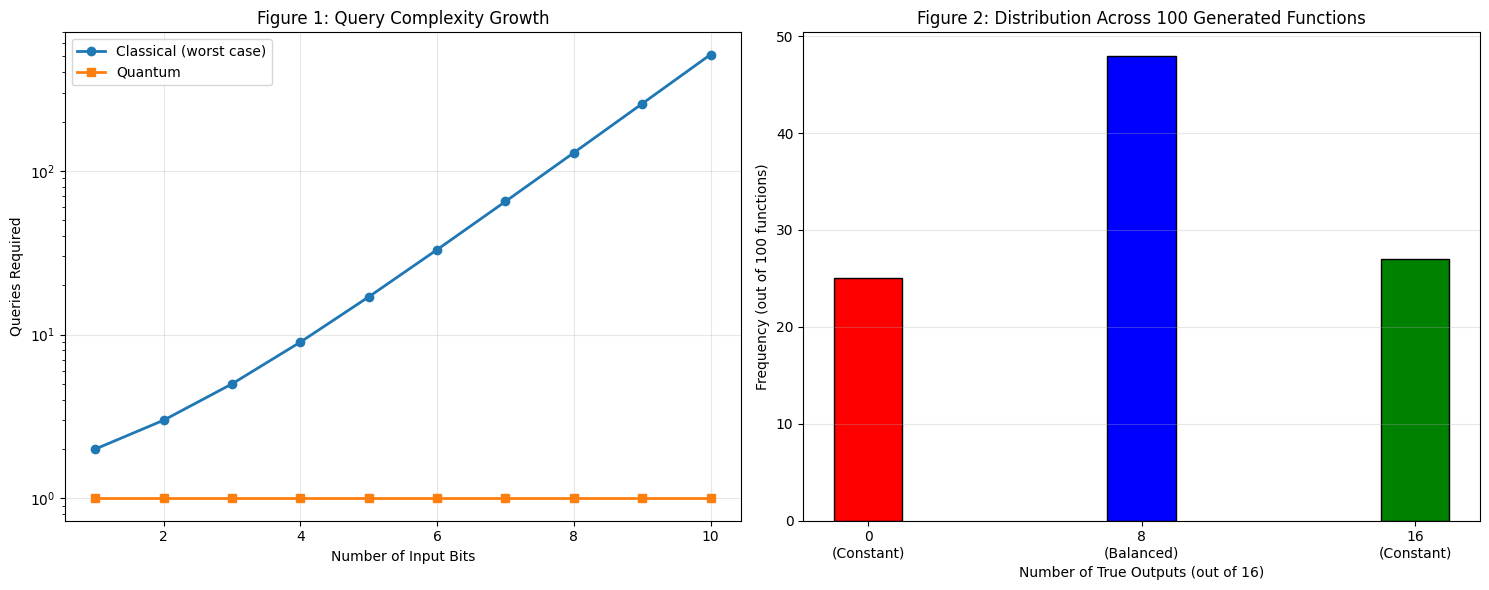

In [54]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 1: Query Complexity Growth
n_bits = np.arange(1, 11)
classical_queries = 2**(n_bits - 1) + 1
quantum_queries = np.ones(len(n_bits))

ax1.plot(n_bits, classical_queries, 'o-', label='Classical (worst case)', linewidth=2)
ax1.plot(n_bits, quantum_queries, 's-', label='Quantum', linewidth=2)
ax1.set_xlabel('Number of Input Bits')
ax1.set_ylabel('Queries Required')
ax1.set_title('Figure 1: Query Complexity Growth')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Figure 2: Distribution of True counts across generated functions
true_counts = []
num_functions = 100

for _ in range(num_functions):
    f = random_constant_balanced()
    all_inputs = list(product([False, True], repeat=4))
    results = [f(*input_combo) for input_combo in all_inputs]
    true_count = sum(results)
    true_counts.append(true_count)

# Count occurrences at each valid value
counts_at_0 = true_counts.count(0)
counts_at_8 = true_counts.count(8)
counts_at_16 = true_counts.count(16)

# Create bar chart
ax2.bar([0, 8, 16], [counts_at_0, counts_at_8, counts_at_16], 
        width=2, color=['red', 'blue', 'green'], edgecolor='black')
ax2.set_xlabel('Number of True Outputs (out of 16)')
ax2.set_ylabel('Frequency (out of 100 functions)')
ax2.set_title('Figure 2: Distribution Across 100 Generated Functions')
ax2.set_xticks([0, 8, 16])
ax2.set_xticklabels(['0\n(Constant)', '8\n(Balanced)', '16\n(Constant)'])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()